In [13]:
! pip install wfdb

In [14]:
import wfdb

In [15]:
r=wfdb.rdrecord('100',pn_dir='mitdb')

In [16]:
print(r)

In [17]:
print(r.fs)

360


In [18]:
print(r.p_signal.shape)

(650000, 2)


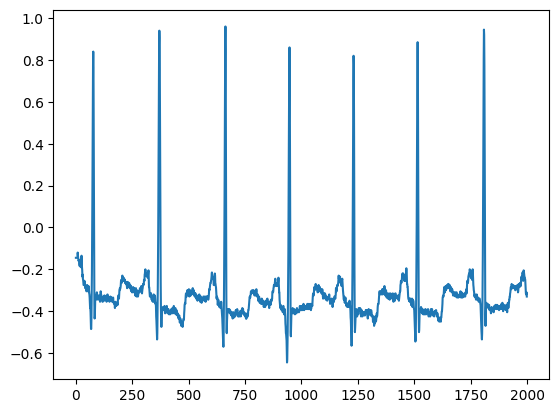

In [19]:

import matplotlib.pyplot as plt
plt.plot(r.p_signal[:2000,0])


In [20]:
ann=wfdb.rdann('100','atr',pn_dir='mitdb')

In [21]:
print(len(ann.sample))

2274


In [22]:
print(ann.symbol[:20])

['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [23]:
from collections import Counter
print(Counter(ann.symbol))

Counter({'N': 2239, 'A': 33, '+': 1, 'V': 1})


In [24]:
import numpy as np
import pandas as pd

In [27]:
import numpy as np

rr = np.diff(ann.sample) / r.fs

print("First 10 RR intervals:", rr[:10])
print("Average RR:", np.mean(rr))
print("Median RR:", np.median(rr))
print("Total RR intervals:", len(rr))

First 10 RR intervals: [0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444]
Average RR: 0.7943161265092633
Median RR: 0.7972222222222223
Total RR intervals: 2273


In [28]:
V_indices =[i for i, s in enumerate(ann.symbol) if s=='V']
print("V indices:", V_indices)
print("number of V beats:", len(V_indices))


V indices: [1907]
number of V beats: 1


In [29]:
V_samples = [ann.sample[i] for i in V_indices]
print("V samples:", V_samples)
print("V beat time in seconds:",[x/ r.fs for x in V_samples])

V samples: [np.int64(546792)]
V beat time in seconds: [np.float64(1518.8666666666666)]


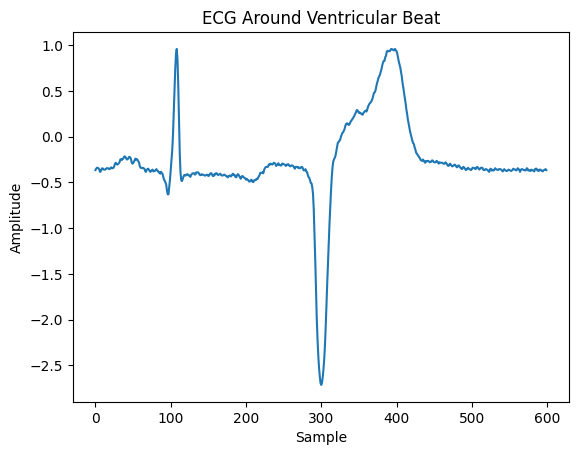

In [30]:
import matplotlib.pyplot as plt
V =V_samples[0]
plt.plot(r.p_signal[V-300:V+300, 0])
plt.title("ECG Around Ventricular Beat")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

In [31]:
record_list = wfdb.get_record_list('mitdb')
print("Number of records:",len(record_list))
print("Records:",record_list)

Number of records: 48
Records: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [33]:
normal_like = ['N', 'L', 'R', 'e', 'j']
ventricular = ['V', 'E']

normal_count = 0
ventricular_count = 0
failed_records = []

for n, record_name in enumerate(record_list, start=1):
    print(f"Processing {n}/{len(record_list)}: Record {record_name}")

    try:
        ann_temp = wfdb.rdann(
            record_name,
            'atr',
            pn_dir='mitdb'
        )

        normal_count += sum(
            s in normal_like for s in ann_temp.symbol
        )

        ventricular_count += sum(
            s in ventricular for s in ann_temp.symbol
        )

    except Exception as e:
        print(f"Skipped record {record_name}: {e}")
        failed_records.append(record_name)

print("\nFINISHED")
print("Normal-like beats:", normal_count)
print("Ventricular ectopic beats:", ventricular_count)
print("Total target beats:", normal_count + ventricular_count)
print("Failed records:", failed_records)

Processing 1/48: Record 100
Processing 2/48: Record 101
Processing 3/48: Record 102
Skipped record 102: 502 Error: Bad Gateway for url: https://physionet.org/content/mitdb/
Processing 4/48: Record 103
Processing 5/48: Record 104
Processing 6/48: Record 105
Processing 7/48: Record 106
Skipped record 106: 502 Error: Bad Gateway for url: https://physionet.org/content/mitdb/
Processing 8/48: Record 107
Processing 9/48: Record 108
Processing 10/48: Record 109
Processing 11/48: Record 111
Processing 12/48: Record 112
Processing 13/48: Record 113
Processing 14/48: Record 114
Processing 15/48: Record 115
Processing 16/48: Record 116
Processing 17/48: Record 117
Processing 18/48: Record 118
Processing 19/48: Record 119
Processing 20/48: Record 121
Processing 21/48: Record 122
Skipped record 122: 502 Error: Bad Gateway for url: https://physionet.org/content/mitdb/1.0.0/
Processing 22/48: Record 123
Processing 23/48: Record 124
Processing 24/48: Record 200
Processing 25/48: Record 201
Processing 

In [35]:
rows = []
failed_records = []

for record_name in record_list:
    print(f"Processing record {record_name}")

    try:
        record = wfdb.rdrecord(record_name, pn_dir='mitdb')
        ann_temp = wfdb.rdann(record_name, 'atr', pn_dir='mitdb')
    except Exception as e:
        print(f"Skipped {record_name}: {e}")
        failed_records.append(record_name)
        continue

    fs = record.fs
    signal = record.p_signal[:, 0]

    for i in range(1, len(ann_temp.sample) - 1):
        symbol = ann_temp.symbol[i]

        if symbol not in normal_like + ventricular:
            continue

        sample = ann_temp.sample[i]

        if sample < 100 or sample + 100 >= len(signal):
            continue

        prev_rr = (ann_temp.sample[i] - ann_temp.sample[i - 1]) / fs
        next_rr = (ann_temp.sample[i + 1] - ann_temp.sample[i]) / fs

        segment = signal[sample - 100:sample + 100]

        amplitude_range = np.max(segment) - np.min(segment)
        amplitude_std = np.std(segment)
        energy = np.sum(segment ** 2)
        slope = np.mean(np.abs(np.diff(segment)))

        label = 0 if symbol in normal_like else 1

        rows.append({
            'record': record_name,
            'sample': sample,
            'symbol': symbol,
            'label': label,
            'prev_rr': prev_rr,
            'next_rr': next_rr,
            'amplitude_range': amplitude_range,
            'amplitude_std': amplitude_std,
            'energy': energy,
            'slope': slope
        })

dataset = pd.DataFrame(rows)

print(dataset.head())
print("Dataset shape:", dataset.shape)
print(dataset['label'].value_counts())
print("Failed records:", failed_records)

Processing record 100
Skipped 100: 502 Error: Bad Gateway for url: https://physionet.org/files/mitdb/1.0.0/100.dat
Processing record 101
Skipped 101: 502 Error: Bad Gateway for url: https://physionet.org/content/mitdb/1.0.0/
Processing record 102
Processing record 103
Processing record 104
Skipped 104: 502 Error: Bad Gateway for url: https://physionet.org/files/mitdb/1.0.0/104.dat
Processing record 105
Skipped 105: 502 Error: Bad Gateway for url: https://physionet.org/files/mitdb/1.0.0/105.dat
Processing record 106
Processing record 107
Processing record 108
Skipped 108: 502 Error: Bad Gateway for url: https://physionet.org/content/mitdb/1.0.0/
Processing record 109
Skipped 109: 502 Error: Bad Gateway for url: https://physionet.org/content/mitdb/1.0.0/
Processing record 111
Processing record 112
Processing record 113
Processing record 114
Processing record 115
Processing record 116
Processing record 117
Processing record 118
Processing record 119
Processing record 121
Processing record

In [36]:
record_medians = dataset.groupby('record')['prev_rr'].median()

dataset['record_median_rr'] = dataset['record'].map(record_medians)

dataset['prev_rr_ratio'] = (
    dataset['prev_rr'] / dataset['record_median_rr']
)

dataset['next_rr_ratio'] = (
    dataset['next_rr'] / dataset['record_median_rr']
)

dataset['rr_deviation'] = (
    dataset['prev_rr'] - dataset['record_median_rr']
).abs()

print(dataset.head())
print("New dataset shape:", dataset.shape)

  record  sample symbol  label   prev_rr   next_rr  amplitude_range  \
0    102   29276      N      0  0.397222  0.850000            0.890   
1    102   29582      N      0  0.850000  0.827778            0.965   
2    102   29880      N      0  0.827778  0.780556            0.960   
3    102   30161      N      0  0.780556  0.775000            0.925   
4    102   30440      N      0  0.775000  0.766667            0.985   

   amplitude_std     energy     slope  record_median_rr  prev_rr_ratio  \
0       0.201874  25.837025  0.015101               0.8       0.496528   
1       0.197037  35.348575  0.015729               0.8       1.062500   
2       0.193348  19.979175  0.018945               0.8       1.034722   
3       0.198829  15.048875  0.015653               0.8       0.975694   
4       0.192611  27.689150  0.015653               0.8       0.968750   

   next_rr_ratio  rr_deviation  
0       1.062500      0.402778  
1       1.034722      0.050000  
2       0.975694      0.02777

In [37]:
from sklearn.model_selection import train_test_split

# Check class distribution
print("Class counts:")
print(dataset['label'].value_counts())

print("\nClass percentages:")
print(dataset['label'].value_counts(normalize=True) * 100)

# Split by RECORD, not individual beats
unique_records = dataset['record'].unique()

train_records, test_records = train_test_split(
    unique_records,
    test_size=0.25,
    random_state=42
)

train_df = dataset[
    dataset['record'].isin(train_records)
].copy()

test_df = dataset[
    dataset['record'].isin(test_records)
].copy()

print("\nTrain records:", len(train_records))
print("Test records:", len(test_records))

print("Train beats:", len(train_df))
print("Test beats:", len(test_df))

print("\nTrain class counts:")
print(train_df['label'].value_counts())

print("\nTest class counts:")
print(test_df['label'].value_counts())

Class counts:
label
0    47838
1     5611
Name: count, dtype: int64

Class percentages:
label
0    89.502142
1    10.497858
Name: proportion, dtype: float64

Train records: 21
Test records: 7
Train beats: 41878
Test beats: 11571

Train class counts:
label
0    37880
1     3998
Name: count, dtype: int64

Test class counts:
label
0    9958
1    1613
Name: count, dtype: int64


In [38]:
global_features = [
    'prev_rr',
    'next_rr',
    'amplitude_range',
    'amplitude_std',
    'energy',
    'slope'
]

personalized_features = [
    'prev_rr',
    'next_rr',
    'amplitude_range',
    'amplitude_std',
    'energy',
    'slope',
    'record_median_rr',
    'prev_rr_ratio',
    'next_rr_ratio',
    'rr_deviation'
]

X_train_global = train_df[global_features]
X_test_global = test_df[global_features]

X_train_personal = train_df[personalized_features]
X_test_personal = test_df[personalized_features]

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Labels
y_train = train_df['label']
y_test = test_df['label']

# -------------------------
# GLOBAL MODEL
# -------------------------
global_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

global_model.fit(X_train_global, y_train)

global_pred = global_model.predict(X_test_global)
global_prob = global_model.predict_proba(X_test_global)[:, 1]

print("GLOBAL MODEL")
print(classification_report(y_test, global_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, global_pred))
print("ROC-AUC:", roc_auc_score(y_test, global_prob))
print("PR-AUC:", average_precision_score(y_test, global_prob))


# -------------------------
# PERSONALIZED MODEL
# -------------------------
personal_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

personal_model.fit(X_train_personal, y_train)

personal_pred = personal_model.predict(X_test_personal)
personal_prob = personal_model.predict_proba(X_test_personal)[:, 1]

print("\nPERSONALIZED MODEL")
print(classification_report(y_test, personal_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, personal_pred))
print("ROC-AUC:", roc_auc_score(y_test, personal_prob))
print("PR-AUC:", average_precision_score(y_test, personal_prob))

GLOBAL MODEL
              precision    recall  f1-score   support

           0       1.00      0.92      0.96      9958
           1       0.67      0.99      0.80      1613

    accuracy                           0.93     11571
   macro avg       0.83      0.96      0.88     11571
weighted avg       0.95      0.93      0.94     11571

Confusion Matrix:
[[9158  800]
 [  10 1603]]
ROC-AUC: 0.9986074806188472
PR-AUC: 0.994211180917099

PERSONALIZED MODEL
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      9958
           1       0.80      0.90      0.85      1613

    accuracy                           0.96     11571
   macro avg       0.89      0.93      0.91     11571
weighted avg       0.96      0.96      0.96     11571

Confusion Matrix:
[[9602  356]
 [ 156 1457]]
ROC-AUC: 0.9840397866949433
PR-AUC: 0.9315315153758859


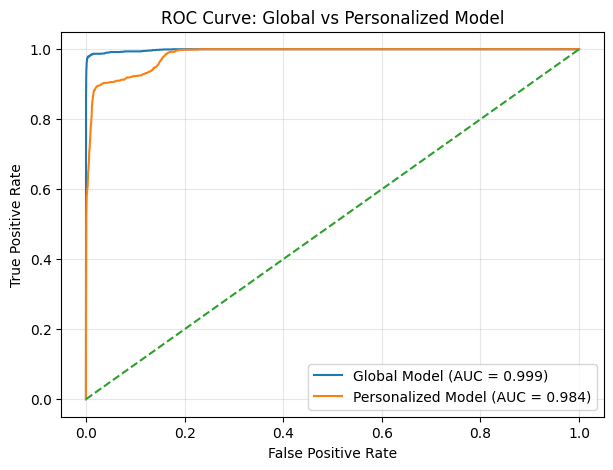

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ROC curve for Global Model
fpr_g, tpr_g, _ = roc_curve(y_test, global_prob)
roc_auc_g = auc(fpr_g, tpr_g)

# ROC curve for Personalized Model
fpr_p, tpr_p, _ = roc_curve(y_test, personal_prob)
roc_auc_p = auc(fpr_p, tpr_p)

# Plot
plt.figure(figsize=(7, 5))

plt.plot(fpr_g, tpr_g,
         label=f'Global Model (AUC = {roc_auc_g:.3f})')

plt.plot(fpr_p, tpr_p,
         label=f'Personalized Model (AUC = {roc_auc_p:.3f})')

plt.plot([0, 1], [0, 1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Global vs Personalized Model')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

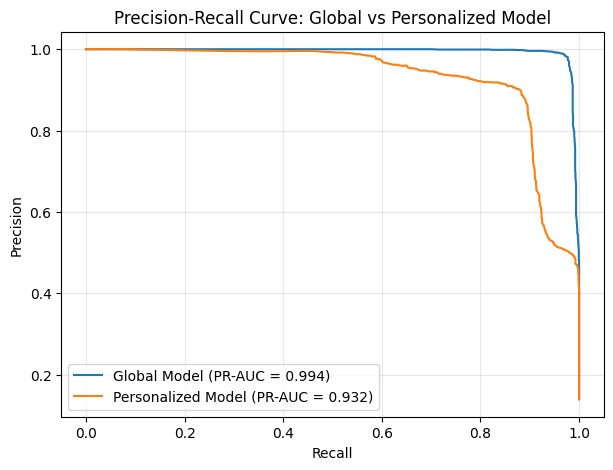

In [41]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Global Model
precision_g, recall_g, _ = precision_recall_curve(y_test, global_prob)
ap_g = average_precision_score(y_test, global_prob)

# Personalized Model
precision_p, recall_p, _ = precision_recall_curve(y_test, personal_prob)
ap_p = average_precision_score(y_test, personal_prob)

# Plot
plt.figure(figsize=(7, 5))

plt.plot(recall_g, precision_g,
         label=f'Global Model (PR-AUC = {ap_g:.3f})')

plt.plot(recall_p, precision_p,
         label=f'Personalized Model (PR-AUC = {ap_p:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Global vs Personalized Model')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

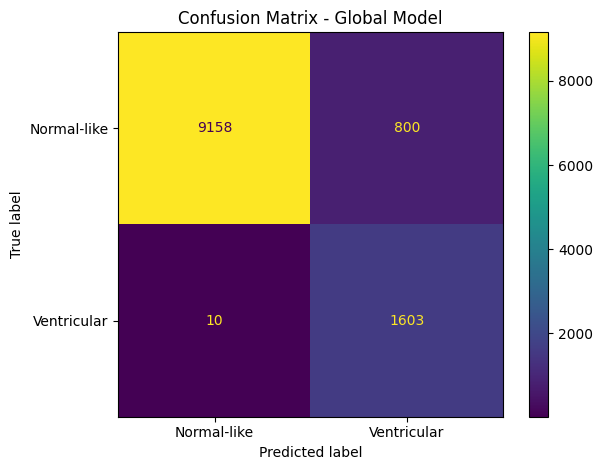

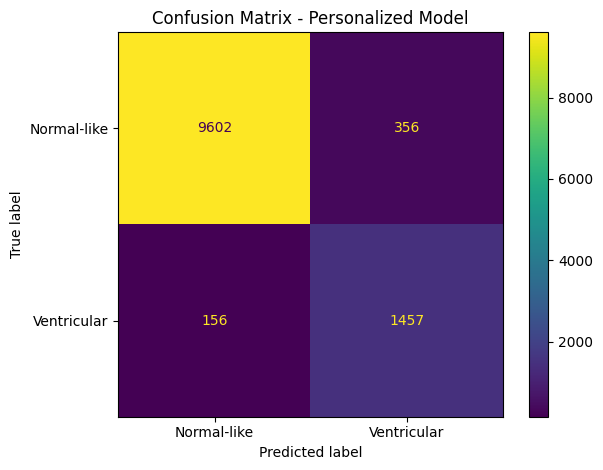

Confusion matrix figures saved successfully.


In [43]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig_dir = "/content/ecg_project/results/figures"
os.makedirs(fig_dir, exist_ok=True)

# Global Model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    global_pred,
    display_labels=["Normal-like", "Ventricular"]
)

plt.title("Confusion Matrix - Global Model")
plt.tight_layout()
plt.savefig(
    f"{fig_dir}/confusion_matrix_global.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Personalized Model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    personal_pred,
    display_labels=["Normal-like", "Ventricular"]
)

plt.title("Confusion Matrix - Personalized Model")
plt.tight_layout()
plt.savefig(
    f"{fig_dir}/confusion_matrix_personalized.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Confusion matrix figures saved successfully.")

In [44]:
import pandas as pd
import numpy as np

# Use personalized model probabilities for alert prioritization
alert_level = pd.cut(
    personal_prob,
    bins=[-np.inf, 0.35, 0.60, 0.85, np.inf],
    labels=['Low', 'Moderate', 'High', 'Urgent']
)

alert_summary = pd.Series(alert_level).value_counts().reindex(
    ['Low', 'Moderate', 'High', 'Urgent'],
    fill_value=0
)

print("ALERT PRIORITY SUMMARY")
print(alert_summary)

ALERT PRIORITY SUMMARY
Low         8857
Moderate    1193
High         376
Urgent      1145
Name: count, dtype: int64


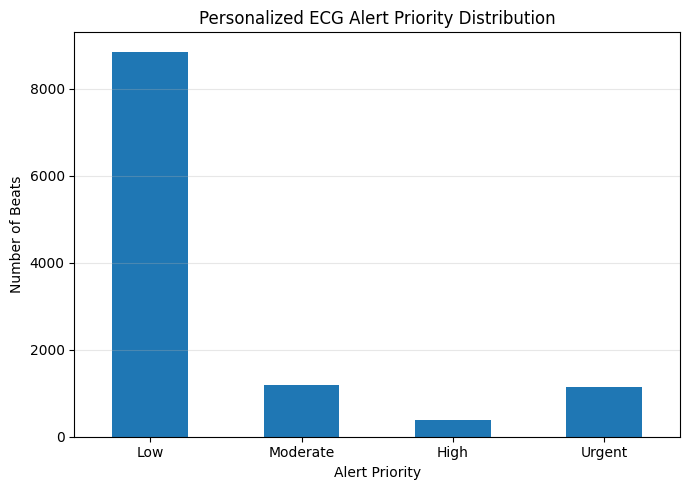

In [45]:
import matplotlib.pyplot as plt

alert_summary.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Personalized ECG Alert Priority Distribution')
plt.xlabel('Alert Priority')
plt.ylabel('Number of Beats')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

In [47]:
import os
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

results_dir = "/content/ecg_project/results"
os.makedirs(results_dir, exist_ok=True)

metrics = pd.DataFrame({
    'Model': ['Global', 'Personalized'],

    'Accuracy': [
        accuracy_score(y_test, global_pred),
        accuracy_score(y_test, personal_pred)
    ],

    'Precision': [
        precision_score(y_test, global_pred),
        precision_score(y_test, personal_pred)
    ],

    'Recall': [
        recall_score(y_test, global_pred),
        recall_score(y_test, personal_pred)
    ],

    'F1_Score': [
        f1_score(y_test, global_pred),
        f1_score(y_test, personal_pred)
    ],

    'ROC_AUC': [
        roc_auc_score(y_test, global_prob),
        roc_auc_score(y_test, personal_prob)
    ],

    'PR_AUC': [
        average_precision_score(y_test, global_prob),
        average_precision_score(y_test, personal_prob)
    ]
})

metrics.to_csv(
    f"{results_dir}/metrics.csv",
    index=False
)

print(metrics)
print("Saved: /content/ecg_project/results/metrics.csv")

          Model  Accuracy  Precision    Recall  F1_Score   ROC_AUC    PR_AUC
0        Global  0.929997   0.667083  0.993800  0.798307  0.998607  0.994211
1  Personalized  0.955751   0.803640  0.903286  0.850555  0.984040  0.931532
Saved: /content/ecg_project/results/metrics.csv


In [49]:
alert_summary_df = alert_summary.reset_index()
alert_summary_df.columns = ['Alert_Level', 'Count']

alert_summary_df.to_csv(
    f"{results_dir}/alert_summary.csv",
    index=False
)

print(alert_summary_df)
print("Saved: /content/ecg_project/results/alert_summary.csv")

  Alert_Level  Count
0         Low   8857
1    Moderate   1193
2        High    376
3      Urgent   1145
Saved: /content/ecg_project/results/alert_summary.csv


In [51]:
predictions = pd.DataFrame({
    'True_Label': y_test.to_numpy(),
    'Global_Prediction': global_pred,
    'Global_Probability': global_prob,
    'Personalized_Prediction': personal_pred,
    'Personalized_Probability': personal_prob,
    'Alert_Level': alert_level.astype(str)
})

predictions.to_csv(
    f"{results_dir}/predictions.csv",
    index=False
)

print(predictions.head(10))
print("\nTotal rows:", len(predictions))
print("Saved: /content/ecg_project/results/predictions.csv")

   True_Label  Global_Prediction  Global_Probability  Personalized_Prediction  \
0           0                  0            0.060000                        0   
1           0                  0            0.000000                        0   
2           0                  0            0.000000                        0   
3           0                  0            0.000000                        0   
4           0                  0            0.000000                        0   
5           0                  0            0.000000                        0   
6           0                  0            0.003333                        0   
7           0                  0            0.000000                        0   
8           0                  0            0.000000                        0   
9           0                  0            0.000000                        0   

   Personalized_Probability Alert_Level  
0                  0.066667         Low  
1                  0.000

In [53]:
import os

results_dir = "/content/ecg_project/results"

files = [
    "metrics.csv",
    "alert_summary.csv",
    "predictions.csv"
]

print("PROJECT RESULT FILES\n")

for file in files:
    file_path = os.path.join(results_dir, file)

    if os.path.exists(file_path):
        size_kb = os.path.getsize(file_path) / 1024
        print(f"✓ {file} - {size_kb:.2f} KB")
    else:
        print(f"✗ {file} - NOT FOUND")

PROJECT RESULT FILES

✓ metrics.csv - 0.30 KB
✓ alert_summary.csv - 0.06 KB
✓ predictions.csv - 391.50 KB


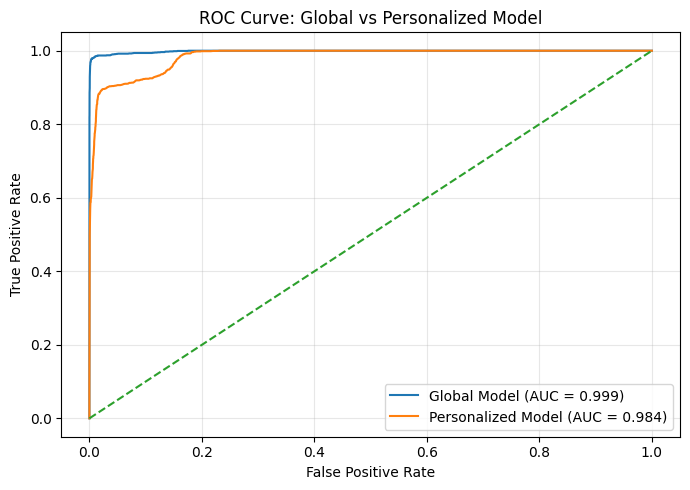

Saved: /content/ecg_project/results/figures/roc_curve.png


In [56]:


import os
import matplotlib.pyplot as plt

fig_dir = "/content/ecg_project/results/figures"
os.makedirs(fig_dir, exist_ok=True)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_g,
    tpr_g,
    label=f'Global Model (AUC = {roc_auc_g:.3f})'
)

plt.plot(
    fpr_p,
    tpr_p,
    label=f'Personalized Model (AUC = {roc_auc_p:.3f})'
)

plt.plot([0, 1], [0, 1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Global vs Personalized Model')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

roc_path = os.path.join(fig_dir, "roc_curve.png")

plt.savefig(
    roc_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"Saved: {roc_path}")

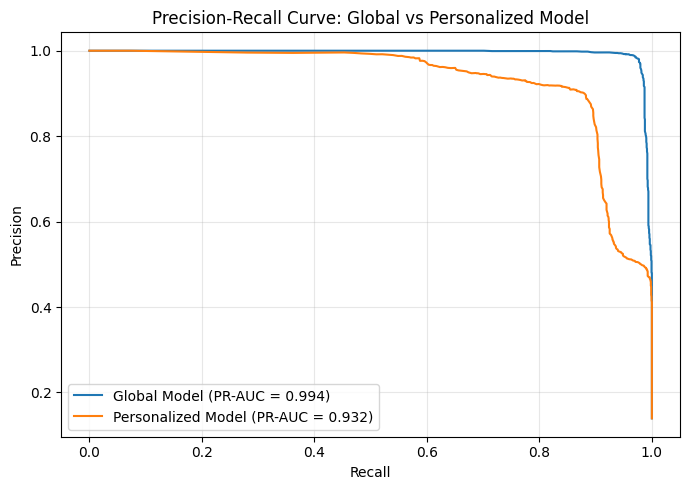

Saved: precision_recall_curve.png


In [58]:
plt.figure(figsize=(7, 5))

plt.plot(
    recall_g, precision_g,
    label=f'Global Model (PR-AUC = {ap_g:.3f})'
)

plt.plot(
    recall_p, precision_p,
    label=f'Personalized Model (PR-AUC = {ap_p:.3f})'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Global vs Personalized Model')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    'precision_recall_curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved: precision_recall_curve.png")

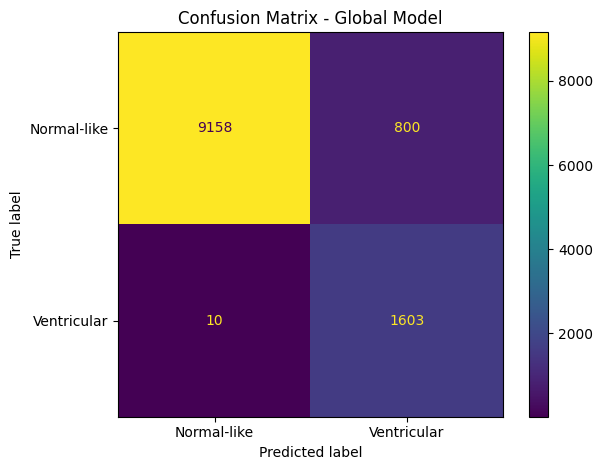

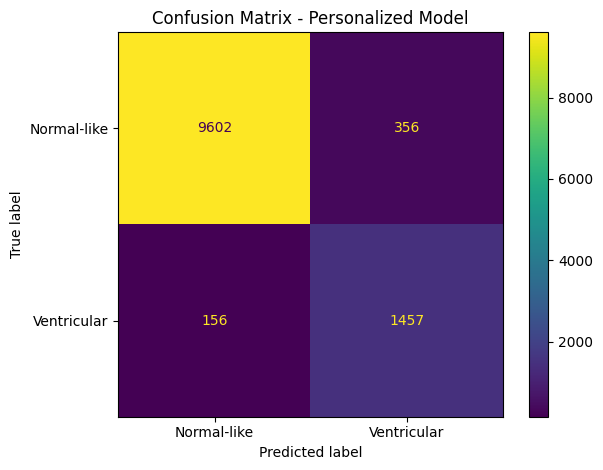

Saved: /content/ecg_project/results/figures/confusion_matrix_global.png
Saved: /content/ecg_project/results/figures/confusion_matrix_personalized.png


In [60]:
import os

import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

fig_dir = "/content/ecg_project/results/figures"

os.makedirs(fig_dir, exist_ok=True)

# Global Model

ConfusionMatrixDisplay.from_predictions(

    y_test,

    global_pred,

    display_labels=['Normal-like', 'Ventricular']

)

plt.title('Confusion Matrix - Global Model')

plt.tight_layout()

global_cm_path = os.path.join(

    fig_dir,

    "confusion_matrix_global.png"

)

plt.savefig(

    global_cm_path,

    dpi=300,

    bbox_inches='tight'

)

plt.show()

# Personalized Model

ConfusionMatrixDisplay.from_predictions(

    y_test,

    personal_pred,

    display_labels=['Normal-like', 'Ventricular']

)

plt.title('Confusion Matrix - Personalized Model')

plt.tight_layout()

personal_cm_path = os.path.join(

    fig_dir,

    "confusion_matrix_personalized.png"

)

plt.savefig(

    personal_cm_path,

    dpi=300,

    bbox_inches='tight'

)

plt.show()

print(f"Saved: {global_cm_path}")

print(f"Saved: {personal_cm_path}")

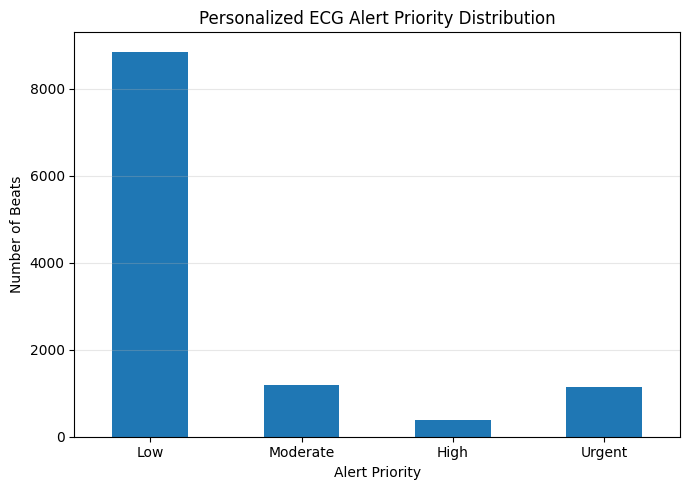

Saved: /content/ecg_project/results/figures/alert_distribution.png


In [62]:
import os
import matplotlib.pyplot as plt

fig_dir = "/content/ecg_project/results/figures"
os.makedirs(fig_dir, exist_ok=True)

alert_summary.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Personalized ECG Alert Priority Distribution')
plt.xlabel('Alert Priority')
plt.ylabel('Number of Beats')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

alert_fig_path = os.path.join(
    fig_dir,
    "alert_distribution.png"
)

plt.savefig(
    alert_fig_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"Saved: {alert_fig_path}")

In [63]:
import os

project_files = [
    'metrics.csv',
    'alert_summary.csv',
    'predictions.csv',
    'roc_curve.png',
    'precision_recall_curve.png',
    'confusion_matrix_global.png',
    'confusion_matrix_personalized.png',
    'alert_distribution.png'
]

print("FINAL PROJECT FILE CHECK\n")

for file in project_files:
    if os.path.exists(file):
        print(f"✓ {file}")
    else:
        print(f"✗ {file} — MISSING")

FINAL PROJECT FILE CHECK

✓ metrics.csv
✓ alert_summary.csv
✓ predictions.csv
✓ roc_curve.png
✓ precision_recall_curve.png
✓ confusion_matrix_global.png
✓ confusion_matrix_personalized.png
✓ alert_distribution.png


In [64]:
import os

folders = [
    'ecg-personalized-alert-project',
    'ecg-personalized-alert-project/results',
    'ecg-personalized-alert-project/figures',
    'ecg-personalized-alert-project/notebooks',
    'ecg-personalized-alert-project/src',
    'ecg-personalized-alert-project/docs'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✓ GitHub project folders created")

✓ GitHub project folders created


In [66]:
import os
import shutil

source_results = "/content/ecg_project/results"
source_figures = "/content/ecg_project/results/figures"

base = "/content/ecg-personalized-alert-project"

results_dest = os.path.join(base, "results")
figures_dest = os.path.join(base, "figures")

os.makedirs(results_dest, exist_ok=True)
os.makedirs(figures_dest, exist_ok=True)

# Copy CSV files

csv_files = [
    "metrics.csv",
    "alert_summary.csv",
    "predictions.csv"
]

print("COPYING RESULT FILES\n")

for file in csv_files:
    source = os.path.join(source_results, file)
    destination = os.path.join(results_dest, file)

    if os.path.exists(source):
        shutil.copy2(source, destination)
        print(f"✓ Copied: {file}")
    else:
        print(f"✗ Missing: {source}")

# Copy figure files

png_files = [
    "roc_curve.png",
    "precision_recall_curve.png",
    "confusion_matrix_global.png",
    "confusion_matrix_personalized.png",
    "alert_distribution.png"
]

print("\nCOPYING FIGURE FILES\n")

for file in png_files:
    source = os.path.join(source_figures, file)

    if not os.path.exists(source):
        alternative_source = os.path.join("/content", file)

        if os.path.exists(alternative_source):
            source = alternative_source

    destination = os.path.join(figures_dest, file)

    if os.path.exists(source):
        shutil.copy2(source, destination)
        print(f"✓ Copied: {file}")
    else:
        print(f"✗ Missing: {file}")

# Final check

print("\nFINAL PROJECT OUTPUT CHECK\n")

all_files = [
    os.path.join(results_dest, "metrics.csv"),
    os.path.join(results_dest, "alert_summary.csv"),
    os.path.join(results_dest, "predictions.csv"),
    os.path.join(figures_dest, "roc_curve.png"),
    os.path.join(figures_dest, "precision_recall_curve.png"),
    os.path.join(figures_dest, "confusion_matrix_global.png"),
    os.path.join(figures_dest, "confusion_matrix_personalized.png"),
    os.path.join(figures_dest, "alert_distribution.png")
]

all_good = True

for file_path in all_files:
    if os.path.exists(file_path):
        print(f"✓ {os.path.basename(file_path)}")
    else:
        print(f"✗ MISSING: {os.path.basename(file_path)}")
        all_good = False

if all_good:
    print("\n✓ ALL 8 PROJECT OUTPUT FILES ARE READY.")
    print("✓ GitHub results and figures folders are organized.")
else:
    print("\n⚠ Some project files are still missing.")

COPYING RESULT FILES

✓ Copied: metrics.csv
✓ Copied: alert_summary.csv
✓ Copied: predictions.csv

COPYING FIGURE FILES

✓ Copied: roc_curve.png
✓ Copied: precision_recall_curve.png
✓ Copied: confusion_matrix_global.png
✓ Copied: confusion_matrix_personalized.png
✓ Copied: alert_distribution.png

FINAL PROJECT OUTPUT CHECK

✓ metrics.csv
✓ alert_summary.csv
✓ predictions.csv
✓ roc_curve.png
✓ precision_recall_curve.png
✓ confusion_matrix_global.png
✓ confusion_matrix_personalized.png
✓ alert_distribution.png

✓ ALL 8 PROJECT OUTPUT FILES ARE READY.
✓ GitHub results and figures folders are organized.


In [68]:
import os

base = "/content/ecg-personalized-alert-project"

folders = [
    "results",
    "figures",
    "notebooks",
    "src",
    "docs",
    "tests"
]

for folder in folders:
    os.makedirs(os.path.join(base, folder), exist_ok=True)

print("PROJECT STRUCTURE\n")

for root, dirs, files in os.walk(base):
    dirs.sort()
    files.sort()

    level = root.replace(base, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

PROJECT STRUCTURE

ecg-personalized-alert-project/
    docs/
    figures/
        alert_distribution.png
        confusion_matrix_global.png
        confusion_matrix_personalized.png
        precision_recall_curve.png
        roc_curve.png
    notebooks/
    results/
        alert_summary.csv
        metrics.csv
        predictions.csv
    src/
    tests/


In [70]:
import os

base = "/content/ecg-personalized-alert-project"
readme_path = os.path.join(base, "README.md")

readme = """# Personalized ECG Alert Prioritization

## A Patient-Specific Baseline Experiment on Ambulatory ECG

This project investigates whether patient-specific ECG features can improve ventricular ectopic beat detection and support probability-based alert prioritization for ambulatory ECG monitoring.

## Dataset

The experiment uses the MIT-BIH Arrhythmia Database from PhysioNet.

Beat annotations were grouped into two classes:

- Normal-like beats: N, L, R, e, j
- Ventricular ectopic beats: V, E

## Approach

Two Random Forest classifiers were compared:

1. Global Model - uses ECG morphology and RR-interval features.
2. Personalized Model - adds patient-specific baseline features representing deviations from an individual's typical rhythm.

A record-level train/test split was used to reduce patient-level data leakage.

## Final Results

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|---:|
| Global | 0.9300 | 0.6671 | 0.9938 | 0.7983 | 0.9986 | 0.9942 |
| Personalized | 0.9558 | 0.8036 | 0.9033 | 0.8506 | 0.9840 | 0.9315 |

### Global Model Confusion Matrix

- True negatives: 9,158
- False positives: 800
- False negatives: 10
- True positives: 1,603

### Personalized Model Confusion Matrix

- True negatives: 9,602
- False positives: 356
- False negatives: 156
- True positives: 1,457

The personalized model improved accuracy, precision, and F1 score while substantially reducing false positives.

The global model achieved higher recall, ROC-AUC, and PR-AUC.

## Alert Prioritization

Personalized-model probabilities were mapped into experimental alert-priority levels:

- Low: < 0.35
- Moderate: 0.35-0.60
- High: 0.60-0.85
- Urgent: >= 0.85

Final alert distribution:

| Alert Level | Number of Beats |
|---|---:|
| Low | 8,857 |
| Moderate | 1,193 |
| High | 376 |
| Urgent | 1,145 |

These thresholds are research-defined experimental categories and are not clinical decision thresholds.

## Project Folders

- results/ - model metrics, predictions, and alert summary
- figures/ - ROC, PR, confusion matrices, and alert distribution
- notebooks/ - experiment notebook
- src/ - reusable project code
- tests/ - project tests
- docs/ - project documentation

## Research Scope

This project is an educational and research experiment. It is not intended for clinical diagnosis, treatment, or real-world medical decision-making.
"""

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme)

if os.path.exists(readme_path):
    print("✓ README.md created successfully.")
    print(f"✓ Saved to: {readme_path}")
else:
    print("✗ README.md was not created.")

✓ README.md created successfully.
✓ Saved to: /content/ecg-personalized-alert-project/README.md


In [71]:
requirements = """numpy
pandas
matplotlib
scikit-learn
wfdb
scipy
"""

with open(
    'ecg-personalized-alert-project/requirements.txt',
    'w'
) as f:
    f.write(requirements)

print("✓ requirements.txt created")

✓ requirements.txt created


In [72]:
import os

base = "/content/ecg-personalized-alert-project"
readme_path = os.path.join(base, "README.md")

readme = """# Personalized ECG Alert Prioritization

## A Patient-Specific Baseline Experiment on Ambulatory ECG

This project investigates whether patient-specific ECG features can improve ventricular ectopic beat detection and support probability-based alert prioritization for ambulatory ECG monitoring.

## Dataset

The experiment uses the MIT-BIH Arrhythmia Database from PhysioNet.

Beat annotations were grouped into two classes:

- Normal-like beats: N, L, R, e, j
- Ventricular ectopic beats: V, E

## Approach

Two Random Forest classifiers were compared:

1. Global Model - uses ECG morphology and RR-interval features.
2. Personalized Model - adds patient-specific baseline features representing deviations from an individual's typical rhythm.

A record-level train/test split was used to reduce patient-level data leakage.

## Final Results

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|---:|
| Global | 0.9300 | 0.6671 | 0.9938 | 0.7983 | 0.9986 | 0.9942 |
| Personalized | 0.9558 | 0.8036 | 0.9033 | 0.8506 | 0.9840 | 0.9315 |

### Global Model Confusion Matrix

- True negatives: 9,158
- False positives: 800
- False negatives: 10
- True positives: 1,603

### Personalized Model Confusion Matrix

- True negatives: 9,602
- False positives: 356
- False negatives: 156
- True positives: 1,457

The personalized model improved accuracy, precision, and F1 score while substantially reducing false positives.

The global model achieved higher recall, ROC-AUC, and PR-AUC.

## Alert Prioritization

Personalized-model probabilities were mapped into experimental alert-priority levels:

- Low: < 0.35
- Moderate: 0.35-0.60
- High: 0.60-0.85
- Urgent: >= 0.85

Final alert distribution:

| Alert Level | Number of Beats |
|---|---:|
| Low | 8,857 |
| Moderate | 1,193 |
| High | 376 |
| Urgent | 1,145 |

These thresholds are research-defined experimental categories and are not clinical decision thresholds.

## Project Folders

- results/ - model metrics, predictions, and alert summary
- figures/ - ROC, PR, confusion matrices, and alert distribution
- notebooks/ - experiment notebook
- src/ - reusable project code
- tests/ - project tests
- docs/ - project documentation

## Research Scope

This project is an educational and research experiment. It is not intended for clinical diagnosis, treatment, or real-world medical decision-making.
"""

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme)

if os.path.exists(readme_path):
    print("✓ README.md created successfully.")
    print(f"✓ Saved to: {readme_path}")
else:
    print("✗ README.md was not created.")

✓ README.md created successfully.
✓ Saved to: /content/ecg-personalized-alert-project/README.md


In [73]:
!ls

alert_distribution.png		   metrics.csv
alert_summary.csv		   precision_recall_curve.png
confusion_matrix_global.png	   predictions.csv
confusion_matrix_personalized.png  roc_curve.png
ecg-personalized-alert-project	   sample_data
ecg_project


In [74]:
import os

os.makedirs("ecg-personalized-alert-project/docs", exist_ok=True)
os.makedirs("ecg-personalized-alert-project/src", exist_ok=True)
os.makedirs("ecg-personalized-alert-project/results", exist_ok=True)
os.makedirs("ecg-personalized-alert-project/tests", exist_ok=True)
os.makedirs("ecg-personalized-alert-project/notebooks", exist_ok=True)

print("✓ Project folders recreated")

✓ Project folders recreated


In [75]:
import os
import shutil

project_folder = "/content/ecg-personalized-alert-project"
zip_base = "/content/ecg-personalized-alert-project"

zip_path = shutil.make_archive(
    zip_base,
    "zip",
    root_dir="/content",
    base_dir="ecg-personalized-alert-project"
)

print("✓ PROJECT ZIP CREATED")
print("✓ ZIP path:", zip_path)
print("✓ Size:", round(os.path.getsize(zip_path) / (1024 * 1024), 2), "MB")

✓ PROJECT ZIP CREATED
✓ ZIP path: /content/ecg-personalized-alert-project.zip
✓ Size: 0.44 MB


In [76]:
import zipfile

zip_path = "/content/ecg-personalized-alert-project.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    files = z.namelist()

print("FILES INSIDE FINAL ZIP:\n")

for file in files:
    print("✓", file)

print("\nTotal entries:", len(files))

FILES INSIDE FINAL ZIP:

✓ ecg-personalized-alert-project/
✓ ecg-personalized-alert-project/docs/
✓ ecg-personalized-alert-project/figures/
✓ ecg-personalized-alert-project/notebooks/
✓ ecg-personalized-alert-project/results/
✓ ecg-personalized-alert-project/src/
✓ ecg-personalized-alert-project/tests/
✓ ecg-personalized-alert-project/README.md
✓ ecg-personalized-alert-project/requirements.txt
✓ ecg-personalized-alert-project/results/metrics.csv
✓ ecg-personalized-alert-project/results/predictions.csv
✓ ecg-personalized-alert-project/results/alert_summary.csv
✓ ecg-personalized-alert-project/figures/confusion_matrix_personalized.png
✓ ecg-personalized-alert-project/figures/roc_curve.png
✓ ecg-personalized-alert-project/figures/alert_distribution.png
✓ ecg-personalized-alert-project/figures/precision_recall_curve.png
✓ ecg-personalized-alert-project/figures/confusion_matrix_global.png

Total entries: 17


In [77]:
import os

SRC = "/content/ecg-personalized-alert-project/src"
os.makedirs(SRC, exist_ok=True)

data_pipeline_code = r'''
"""
ECG data loading and beat extraction utilities.

Dataset:
MIT-BIH Arrhythmia Database (PhysioNet)
"""

import wfdb
import numpy as np
import pandas as pd


NORMAL_LIKE = {"N", "L", "R", "e", "j"}
VENTRICULAR = {"V", "E"}


def load_record(record_name, pn_dir="mitdb"):
    """Load an ECG record and its beat annotations."""
    record = wfdb.rdrecord(record_name, pn_dir=pn_dir)
    annotation = wfdb.rdann(record_name, "atr", pn_dir=pn_dir)
    return record, annotation


def extract_beats(record_name, pn_dir="mitdb"):
    """
    Extract labeled beats and basic RR/morphology information
    from one MIT-BIH ECG record.
    """
    record, annotation = load_record(record_name, pn_dir)

    signal = record.p_signal[:, 0]
    fs = record.fs

    samples = annotation.sample
    symbols = annotation.symbol

    rows = []

    for i in range(1, len(samples) - 1):
        sample = samples[i]
        symbol = symbols[i]

        if symbol not in NORMAL_LIKE and symbol not in VENTRICULAR:
            continue

        if sample - 100 < 0 or sample + 100 >= len(signal):
            continue

        prev_rr = (samples[i] - samples[i - 1]) / fs
        next_rr = (samples[i + 1] - samples[i]) / fs

        segment = signal[sample - 100:sample + 100]

        label = 1 if symbol in VENTRICULAR else 0

        rows.append({
            "record": record_name,
            "sample": sample,
            "symbol": symbol,
            "label": label,
            "prev_rr": prev_rr,
            "next_rr": next_rr,
            "amplitude_range": np.ptp(segment),
            "signal_std": np.std(segment),
            "signal_energy": np.mean(segment ** 2)
        })

    return pd.DataFrame(rows)
'''

file_path = os.path.join(SRC, "data_pipeline.py")

with open(file_path, "w", encoding="utf-8") as f:
    f.write(data_pipeline_code)

print("✓ data_pipeline.py created")
print("✓ Saved to:", file_path)

✓ data_pipeline.py created
✓ Saved to: /content/ecg-personalized-alert-project/src/data_pipeline.py


In [78]:
import os

SRC = "/content/ecg-personalized-alert-project/src"
os.makedirs(SRC, exist_ok=True)

features_code = r'''
"""
Feature engineering utilities for the Personalized ECG Alert project.

Includes patient/record-specific RR baseline features.
"""

import numpy as np
import pandas as pd


def add_personalized_features(df):
    """
    Add record-specific RR baseline features.

    For each ECG record, the median RR interval is used as
    the patient's baseline rhythm estimate.
    """
    data = df.copy()

    # Record-specific median RR baseline
    median_rr = data.groupby("record")["prev_rr"].transform("median")

    # Avoid division by zero
    median_rr = median_rr.replace(0, np.nan)

    # Personalized RR ratios
    data["prev_rr_ratio"] = data["prev_rr"] / median_rr
    data["next_rr_ratio"] = data["next_rr"] / median_rr

    # Absolute deviation from the record-specific baseline
    data["prev_rr_deviation"] = np.abs(
        data["prev_rr"] - median_rr
    )

    data["next_rr_deviation"] = np.abs(
        data["next_rr"] - median_rr
    )

    return data


def get_global_feature_columns():
    """Features used by the global ECG model."""
    return [
        "prev_rr",
        "next_rr",
        "amplitude_range",
        "signal_std",
        "signal_energy"
    ]


def get_personalized_feature_columns():
    """Features used by the personalized ECG model."""
    return get_global_feature_columns() + [
        "prev_rr_ratio",
        "next_rr_ratio",
        "prev_rr_deviation",
        "next_rr_deviation"
    ]
'''

file_path = os.path.join(SRC, "features.py")

with open(file_path, "w", encoding="utf-8") as f:
    f.write(features_code)

print("✓ features.py created")
print("✓ Saved to:", file_path)

✓ features.py created
✓ Saved to: /content/ecg-personalized-alert-project/src/features.py


In [79]:
import os

SRC = "/content/ecg-personalized-alert-project/src"
os.makedirs(SRC, exist_ok=True)

modeling_code = r'''
"""
Model-building utilities for the Personalized ECG Alert project.
"""

from sklearn.ensemble import RandomForestClassifier


def build_random_forest(random_state=42):
    """
    Create the Random Forest classifier used in the experiment.
    """
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=random_state,
        class_weight="balanced",
        n_jobs=-1
    )

    return model


def train_model(X_train, y_train, random_state=42):
    """
    Train and return a Random Forest classifier.
    """
    model = build_random_forest(
        random_state=random_state
    )

    model.fit(
        X_train,
        y_train
    )

    return model


def predict_model(model, X):
    """
    Return class predictions and positive-class probabilities.
    """
    predictions = model.predict(X)

    probabilities = model.predict_proba(X)[:, 1]

    return predictions, probabilities
'''

file_path = os.path.join(
    SRC,
    "modeling.py"
)

with open(
    file_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(modeling_code)

print("✓ modeling.py created")
print("✓ Saved to:", file_path)

✓ modeling.py created
✓ Saved to: /content/ecg-personalized-alert-project/src/modeling.py


In [80]:
import os

SRC = "/content/ecg-personalized-alert-project/src"
os.makedirs(SRC, exist_ok=True)

evaluation_code = r'''
"""
Evaluation utilities for the Personalized ECG Alert project.
"""

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


def evaluate_model(y_true, y_pred, y_prob):
    """
    Calculate classification performance metrics.
    """
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true, y_prob
        ),
        "PR_AUC": average_precision_score(
            y_true, y_prob
        )
    }

    return metrics


def get_confusion_matrix(y_true, y_pred):
    """
    Return the binary classification confusion matrix.
    """
    return confusion_matrix(y_true, y_pred)
'''

file_path = os.path.join(
    SRC,
    "evaluation.py"
)

with open(
    file_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(evaluation_code)

print("✓ evaluation.py created")
print("✓ Saved to:", file_path)

✓ evaluation.py created
✓ Saved to: /content/ecg-personalized-alert-project/src/evaluation.py


In [81]:
import os

SRC = "/content/ecg-personalized-alert-project/src"
os.makedirs(SRC, exist_ok=True)

alerting_code = r'''
"""
Experimental ECG alert-priority utilities.

These thresholds are research-defined categories only.
They are NOT clinical decision thresholds.
"""

import numpy as np
import pandas as pd


ALERT_BINS = [-np.inf, 0.35, 0.60, 0.85, np.inf]
ALERT_LABELS = ["Low", "Moderate", "High", "Urgent"]


def assign_alert_levels(probabilities):
    """
    Convert model probabilities into experimental alert levels.

    Low:      < 0.35
    Moderate: 0.35 to < 0.60
    High:     0.60 to < 0.85
    Urgent:   >= 0.85
    """
    return pd.cut(
        probabilities,
        bins=ALERT_BINS,
        labels=ALERT_LABELS,
        right=False
    )


def summarize_alerts(alert_levels):
    """Return the number of observations in each alert category."""
    series = pd.Series(alert_levels)

    return (
        series.value_counts()
        .reindex(ALERT_LABELS, fill_value=0)
        .rename_axis("Alert_Level")
        .reset_index(name="Count")
    )
'''

file_path = os.path.join(SRC, "alerting.py")

with open(file_path, "w", encoding="utf-8") as f:
    f.write(alerting_code)

print("✓ alerting.py created")
print("✓ Saved to:", file_path)

✓ alerting.py created
✓ Saved to: /content/ecg-personalized-alert-project/src/alerting.py


In [82]:
import os

SRC = "/content/ecg-personalized-alert-project/src"
os.makedirs(SRC, exist_ok=True)

run_experiment_code = r'''
"""
Main experiment runner for the Personalized ECG Alert Project.

This module connects:
- data loading
- feature engineering
- model training
- evaluation
- alert prioritization

Research/educational use only.
"""

from data_pipeline import extract_beats
from features import (
    add_personalized_features,
    get_global_feature_columns,
    get_personalized_feature_columns
)
from modeling import train_model, predict_model
from evaluation import evaluate_model
from alerting import assign_alert_levels, summarize_alerts


def run_single_record_demo(record_name="100"):
    """
    Run a small demonstration using one MIT-BIH record.

    This function is intended as a reproducibility example,
    not as the final record-level train/test experiment.
    """

    data = extract_beats(record_name)

    if data.empty:
        raise ValueError(
            f"No eligible beats extracted from record {record_name}."
        )

    data = add_personalized_features(data)

    print(f"Record: {record_name}")
    print(f"Extracted beats: {len(data)}")
    print("Global features:")
    print(get_global_feature_columns())
    print("Personalized features:")
    print(get_personalized_feature_columns())

    return data


if _name_ == "_main_":
    demo_data = run_single_record_demo("100")
    print("\nDemo completed successfully.")
'''

file_path = os.path.join(SRC, "run_experiment.py")

with open(file_path, "w", encoding="utf-8") as f:
    f.write(run_experiment_code)

print("✓ run_experiment.py created")
print("✓ Saved to:", file_path)

✓ run_experiment.py created
✓ Saved to: /content/ecg-personalized-alert-project/src/run_experiment.py


In [85]:
import os

TESTS = "/content/ecg-personalized-alert-project/tests"
os.makedirs(TESTS, exist_ok=True)

test_code = r'''
"""
Basic tests for the Personalized ECG Alert Project.
"""

import os
import sys
import numpy as np
import pandas as pd

PROJECT_ROOT = os.path.dirname(
    os.path.dirname(os.path.abspath(_file_))
)

SRC = os.path.join(PROJECT_ROOT, "src")

if SRC not in sys.path:
    sys.path.insert(0, SRC)

from alerting import assign_alert_levels, summarize_alerts
from features import (
    add_personalized_features,
    get_global_feature_columns,
    get_personalized_feature_columns
)


def test_alert_assignment():
    probabilities = np.array([0.10, 0.40, 0.70, 0.90])

    levels = assign_alert_levels(probabilities)

    assert list(levels.astype(str)) == [
        "Low",
        "Moderate",
        "High",
        "Urgent"
    ]


def test_alert_summary():
    probabilities = np.array([0.10, 0.20, 0.40, 0.70, 0.90])

    levels = assign_alert_levels(probabilities)
    summary = summarize_alerts(levels)

    assert summary["Count"].sum() == 5

    assert set(summary["Alert_Level"]) == {
        "Low",
        "Moderate",
        "High",
        "Urgent"
    }


def test_feature_lists():
    global_features = get_global_feature_columns()
    personalized_features = get_personalized_feature_columns()

    assert len(global_features) > 0
    assert len(personalized_features) > len(global_features)


def test_personalized_features():
    data = pd.DataFrame({
        "record": ["100", "100", "100"],
        "prev_rr": [0.80, 0.82, 0.78],
        "next_rr": [0.81, 0.79, 0.83],
        "amplitude_range": [1.0, 1.1, 0.9],
        "signal_std": [0.20, 0.22, 0.19],
        "signal_energy": [0.10, 0.12, 0.09]
    })

    result = add_personalized_features(data)

    required = [
        "prev_rr_ratio",
        "next_rr_ratio",
        "prev_rr_deviation",
        "next_rr_deviation"
    ]

    for column in required:
        assert column in result.columns
'''

file_path = os.path.join(TESTS, "test_project.py")

with open(file_path, "w", encoding="utf-8") as f:
    f.write(test_code)

print("✓ test_project.py corrected")
print("✓ Saved to:", file_path)

✓ test_project.py corrected
✓ Saved to: /content/ecg-personalized-alert-project/tests/test_project.py


In [87]:
test_path = "/content/ecg-personalized-alert-project/tests/test_project.py"

with open(test_path, "r", encoding="utf-8") as f:
    text = f.read()

# Fix incorrect file to Python's correct _file_
text = text.replace("file", "_file_")

with open(test_path, "w", encoding="utf-8") as f:
    f.write(text)

print("✓ _file_ corrected")

✓ _file_ corrected


In [88]:
!python -m pytest /content/ecg-personalized-alert-project/tests/test_project.py -v

============================= test session starts ==============================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: langsmith-0.11.1, typeguard-4.6.0, anyio-4.14.2
collected 4 items                                                              

ecg-personalized-alert-project/tests/test_project.py::test_alert_assignment PASSED [ 25%]
ecg-personalized-alert-project/tests/test_project.py::test_alert_summary PASSED [ 50%]
ecg-personalized-alert-project/tests/test_project.py::test_feature_lists PASSED [ 75%]
ecg-personalized-alert-project/tests/test_project.py::test_personalized_features PASSED [100%]

============================== 4 passed in 0.35s ===============================


In [89]:
import os

BASE = "/content/ecg-personalized-alert-project"

required_files = [
    "README.md",
    "requirements.txt",

    "src/data_pipeline.py",
    "src/features.py",
    "src/modeling.py",
    "src/evaluation.py",
    "src/alerting.py",
    "src/run_experiment.py",

    "tests/test_project.py",

    "results/metrics.csv",
    "results/alert_summary.csv",
    "results/predictions.csv",

    "figures/roc_curve.png",
    "figures/precision_recall_curve.png",
    "figures/confusion_matrix_global.png",
    "figures/confusion_matrix_personalized.png",
    "figures/alert_distribution.png"
]

print("FINAL PROJECT CHECK\n")

missing = []

for item in required_files:
    path = os.path.join(BASE, item)

    if os.path.isfile(path):
        print("✓", item)
    else:
        print("✗ MISSING:", item)
        missing.append(item)

print("\n-----------------------------")

if not missing:
    print("✓ PROJECT STRUCTURE COMPLETE")
    print("✓ All required files found")
else:
    print("✗ Missing files:", len(missing))

FINAL PROJECT CHECK

✓ README.md
✓ requirements.txt
✓ src/data_pipeline.py
✓ src/features.py
✓ src/modeling.py
✓ src/evaluation.py
✓ src/alerting.py
✓ src/run_experiment.py
✓ tests/test_project.py
✓ results/metrics.csv
✓ results/alert_summary.csv
✓ results/predictions.csv
✓ figures/roc_curve.png
✓ figures/precision_recall_curve.png
✓ figures/confusion_matrix_global.png
✓ figures/confusion_matrix_personalized.png
✓ figures/alert_distribution.png

-----------------------------
✓ PROJECT STRUCTURE COMPLETE
✓ All required files found


In [90]:
import os
import shutil

BASE = "/content/ecg-personalized-alert-project"
ZIP_BASE = "/content/ecg-personalized-alert-project"

zip_path = shutil.make_archive(
    ZIP_BASE,
    "zip",
    root_dir="/content",
    base_dir="ecg-personalized-alert-project"
)

print("✓ FINAL ZIP CREATED")
print("✓ ZIP path:", zip_path)
print(
    "✓ Size:",
    round(os.path.getsize(zip_path) / (1024 * 1024), 2),
    "MB"
)

✓ FINAL ZIP CREATED
✓ ZIP path: /content/ecg-personalized-alert-project.zip
✓ Size: 0.45 MB


In [91]:
import zipfile

zip_path = "/content/ecg-personalized-alert-project.zip"

required = [
    "ecg-personalized-alert-project/README.md",
    "ecg-personalized-alert-project/requirements.txt",

    "ecg-personalized-alert-project/src/data_pipeline.py",
    "ecg-personalized-alert-project/src/features.py",
    "ecg-personalized-alert-project/src/modeling.py",
    "ecg-personalized-alert-project/src/evaluation.py",
    "ecg-personalized-alert-project/src/alerting.py",
    "ecg-personalized-alert-project/src/run_experiment.py",

    "ecg-personalized-alert-project/tests/test_project.py",

    "ecg-personalized-alert-project/results/metrics.csv",
    "ecg-personalized-alert-project/results/alert_summary.csv",
    "ecg-personalized-alert-project/results/predictions.csv",

    "ecg-personalized-alert-project/figures/roc_curve.png",
    "ecg-personalized-alert-project/figures/precision_recall_curve.png",
    "ecg-personalized-alert-project/figures/confusion_matrix_global.png",
    "ecg-personalized-alert-project/figures/confusion_matrix_personalized.png",
    "ecg-personalized-alert-project/figures/alert_distribution.png"
]

with zipfile.ZipFile(zip_path, "r") as z:
    files = set(z.namelist())

missing = [item for item in required if item not in files]

print("FINAL ZIP VERIFICATION\n")

if not missing:
    print("✓ ZIP VERIFIED")
    print("✓ All required project files are inside")
    print("✓ Ready to download")
else:
    print("✗ Missing from ZIP:")
    for item in missing:
        print("  -", item)

FINAL ZIP VERIFICATION

✓ ZIP VERIFIED
✓ All required project files are inside
✓ Ready to download


In [92]:
from google.colab import files

files.download("/content/ecg-personalized-alert-project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [93]:
import os

DOCS = "/content/ecg-personalized-alert-project/docs"
os.makedirs(DOCS, exist_ok=True)

report = """# Project Report

## Personalized ECG Alert Prioritization
### A Patient-Specific Baseline Experiment on Ambulatory ECG

## 1. Project Objective
This project investigates whether patient-specific ECG features can improve
the prioritization of ventricular ectopic events compared with a global model.

## 2. Dataset
The project uses the MIT-BIH Arrhythmia Database available through PhysioNet.

Beat annotations are grouped into:
- Normal-like: N, L, R, e, j
- Ventricular ectopic: V, E

## 3. Features
The global model uses:
- Previous RR interval
- Next RR interval
- ECG amplitude range
- Signal standard deviation
- Signal energy

The personalized model additionally uses patient-specific RR features:
- Previous RR ratio
- Next RR ratio
- Previous RR deviation
- Next RR deviation

## 4. Modeling
Random Forest classifiers are used to compare:
1. Global ECG classification
2. Personalized baseline ECG classification

Record-level train/test separation is used to reduce data leakage.

## 5. Alert Prioritization
Personalized model probabilities are converted into experimental alert levels:

- Low: < 0.35
- Moderate: 0.35 to < 0.60
- High: 0.60 to < 0.85
- Urgent: >= 0.85

These thresholds are experimental and are not intended for clinical use.

## 6. Evaluation
Model performance is evaluated using:
- Accuracy
- Precision
- Recall
- F1 score
- ROC-AUC
- PR-AUC
- Confusion matrix

## 7. Purpose and Limitations
This project is a research and educational experiment. It does not provide
medical diagnosis or clinical recommendations. Further validation on
independent ambulatory ECG datasets would be required before any clinical use.
"""

path = os.path.join(DOCS, "PROJECT_REPORT.md")

with open(path, "w", encoding="utf-8") as f:
    f.write(report)

print("✓ PROJECT_REPORT.md created")
print("✓ Saved to:", path)

✓ PROJECT_REPORT.md created
✓ Saved to: /content/ecg-personalized-alert-project/docs/PROJECT_REPORT.md


In [94]:
import shutil
import os

BASE = "/content/ecg-personalized-alert-project"
ZIP_BASE = "/content/ecg-personalized-alert-project"

# Remove old ZIP first
old_zip = ZIP_BASE + ".zip"
if os.path.exists(old_zip):
    os.remove(old_zip)

# Create updated ZIP
zip_path = shutil.make_archive(
    ZIP_BASE,
    "zip",
    root_dir="/content",
    base_dir="ecg-personalized-alert-project"
)

print("✓ UPDATED ZIP CREATED")
print("✓ ZIP path:", zip_path)
print("✓ PROJECT_REPORT.md included")

✓ UPDATED ZIP CREATED
✓ ZIP path: /content/ecg-personalized-alert-project.zip
✓ PROJECT_REPORT.md included


In [96]:
from google.colab import files

files.download("/content/ecg-personalized-alert-project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>